In [ ]:
from google.colab import files
files.upload()

Saving parent_child_genetic_dataset.csv to parent_child_genetic_dataset.csv


{'parent_child_genetic_dataset.csv': b'Father_Gene_Risk,Mother_Gene_Risk,Consanguinity,Family_History,Child_Disease\n2,2,1,0,1\n0,1,1,0,0\n2,1,1,1,1\n2,0,0,0,1\n0,1,1,0,0\n0,1,0,1,0\n2,2,0,1,0\n1,1,0,1,1\n2,2,0,1,0\n2,1,1,1,0\n2,1,1,1,1\n2,1,1,0,1\n0,0,1,0,0\n2,2,0,0,0\n1,0,0,1,1\n0,1,0,1,1\n1,0,0,0,1\n1,2,1,0,0\n1,1,1,1,0\n1,0,0,1,1\n0,0,0,0,1\n0,2,0,0,1\n1,0,0,0,0\n1,2,1,0,0\n0,1,0,0,0\n0,1,1,1,0\n0,0,1,0,1\n2,1,0,0,1\n2,1,0,1,0\n2,0,1,0,1\n1,1,1,1,1\n2,0,0,1,0\n1,2,1,0,1\n1,2,0,0,0\n2,2,0,1,0\n1,0,1,1,0\n2,0,1,1,1\n2,1,0,0,0\n0,1,0,0,1\n2,1,1,0,1\n0,1,1,0,0\n2,1,1,0,0\n2,0,1,1,0\n0,0,0,0,0\n0,2,0,0,0\n2,2,0,1,1\n1,2,1,0,1\n0,2,1,0,1\n1,0,0,0,0\n1,0,1,1,0\n1,0,1,1,1\n0,1,1,0,0\n1,1,1,0,1\n0,2,1,0,1\n1,1,1,1,1\n2,0,0,1,0\n2,2,0,0,0\n0,2,0,0,1\n2,1,0,0,0\n2,2,1,0,0\n1,1,0,1,0\n0,1,0,1,1\n1,2,0,0,1\n1,1,0,1,1\n1,1,1,1,1\n1,1,1,0,1\n1,1,0,0,0\n1,2,0,0,1\n1,0,1,0,0\n0,0,1,1,1\n2,1,0,0,0\n1,1,1,0,0\n1,1,1,0,1\n1,0,0,0,0\n1,1,1,1,0\n1,2,0,0,0\n1,2,0,0,0\n2,2,1,1,0\n2,0,1,0,0\n1,1,1,0,1\n2,1

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
import os
os.listdir()

['.config', 'parent_child_genetic_dataset.csv', 'sample_data']

In [4]:
df = pd.read_csv("parent_child_genetic_dataset.csv")
df.head()

,Father_Gene_Risk,Mother_Gene_Risk,Consanguinity,Family_History,Child_Disease
0,2,2,1,0,1
1,0,1,1,0,0
2,2,1,1,1,1
3,2,0,0,0,1
4,0,1,1,0,0


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Father_Gene_Risk  10000 non-null  int64
 1   Mother_Gene_Risk  10000 non-null  int64
 2   Consanguinity     10000 non-null  int64
 3   Family_History    10000 non-null  int64
 4   Child_Disease     10000 non-null  int64
dtypes: int64(5)
memory usage: 390.8 KB


In [6]:
df["Child_Disease"] = (
    (df["Father_Gene_Risk"]*2 +
     df["Mother_Gene_Risk"]*2 +
     df["Consanguinity"]*3 +
     df["Family_History"]*3) >= 8
).astype(int)

In [7]:
df["Child_Disease"].value_counts()

,count
Child_Disease,
0,5931
1,4069


In [8]:
X = df.drop("Child_Disease", axis=1)
y = df["Child_Disease"]

In [9]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, train_size=8000, test_size=2000, random_state=42
)

print("Training:", X_train.shape)
print("Testing:", X_test.shape)

Training: (8000, 4)
Testing: (2000, 4)


In [10]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=300,
    max_depth=10,
    class_weight="balanced",
    random_state=42
)

model.fit(X_train, y_train)
print("Model trained")

Model trained


In [11]:
from sklearn.metrics import accuracy_score

y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 1.0


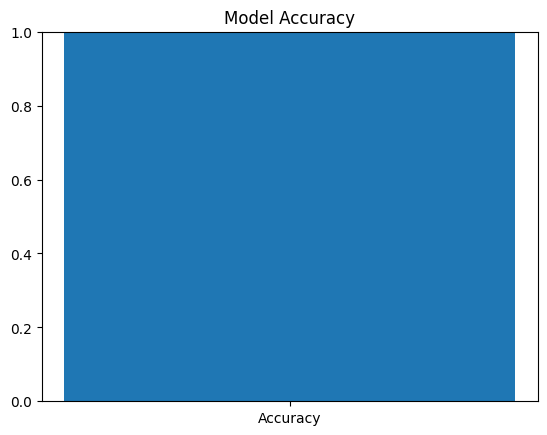

In [12]:
plt.figure()
plt.bar(["Accuracy"], [accuracy])
plt.ylim(0,1)
plt.title("Model Accuracy")
plt.show()

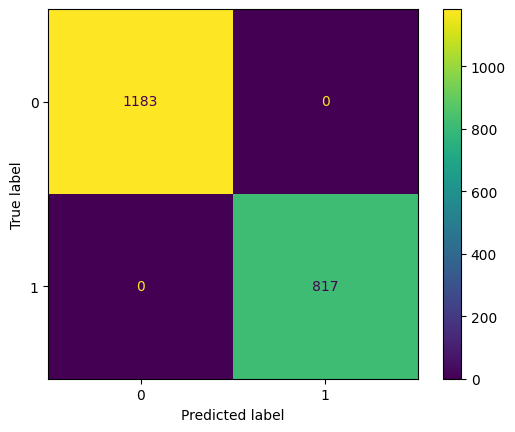

In [13]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(confusion_matrix=cm).plot()
plt.show()

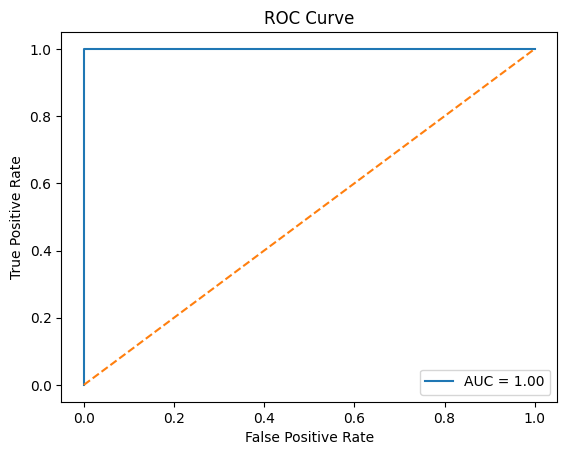

In [14]:
c

In [15]:
# ===== FINAL USER INPUT CELL =====

father = int(input("Father Gene Risk (0=Low,1=Medium,2=High): "))
mother = int(input("Mother Gene Risk (0=Low,1=Medium,2=High): "))
cons = int(input("Consanguinity (0=No,1=Yes): "))
history = int(input("Family History (0=No,1=Yes): "))

import pandas as pd
user_input = pd.DataFrame(
    [[father, mother, cons, history]],
    columns=[
        "Father_Gene_Risk",
        "Mother_Gene_Risk",
        "Consanguinity",
        "Family_History"
    ]
)

prediction = model.predict(user_input)
probability = model.predict_proba(user_input)

if prediction[0] == 1:
    print("⚠ Child may have genetic disorder")
else:
    print("✅ Child likely healthy")

print("Disease Probability:", round(probability[0][1]*100, 2), "%")

Father Gene Risk (0=Low,1=Medium,2=High): 2
Mother Gene Risk (0=Low,1=Medium,2=High): 2
Consanguinity (0=No,1=Yes): 1
Family History (0=No,1=Yes): 0
⚠ Child may have genetic disorder
Disease Probability: 100.0 %


In [16]:
import joblib
joblib.dump(model, "child_genetic_model.pkl")
print("Model saved")

Model saved


In [17]:
from google.colab import files
files.download("child_genetic_model.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>